ДЗ: 1, 2, 3


# Распределение степеней узлов

__Авторы задач: Макрушин С.В (SVMakrushin@fa.ru), Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* Макрушин С.В. "Лекция 2: Модели"
* Документация:
    * https://networkx.org/documentation/stable/reference/generated/networkx.linalg.graphmatrix.adjacency_matrix.html
    * https://networkx.org/documentation/stable/reference/classes/generated/networkx.Graph.degree.html
    * https://networkx.org/documentation/stable/reference/classes/generated/networkx.DiGraph.in_degree.html
    * https://networkx.org/documentation/stable/reference/classes/generated/networkx.DiGraph.out_degree.html
* Дополнительные источники:
    * https://www.scaler.com/topics/matplotlib/logarithmic-scale-matplotlib/
* Датасеты с сетями:
    * http://networkrepository.com

## Вопросы для совместного обсуждения

1\. Обсудите различные подходы к вычислению степеней узлов графа.

2\. Обсудите использование различных шкал (линейной, логарифмической) для визуализациии графиков.

## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Создайте неориентированный граф на основе набора данных `fb-pages-food` с сайта https://networkrepository.com/. Добавьте узлам атрибут `name`, который содержит имя человека. Удалите из графа все петли. Получите матрицу смежности графа и посчитайте степень каждого узла на основе этой матрицы. Выведите имя человека, чей узел имеет максимальную степень, и само значение степени.

- [ ] Проверено на семинаре

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import csv

In [2]:
g = nx.read_adjlist('/content/fb-pages-food.edges', delimiter=',')


In [3]:
node_names = {}
with open("fb-pages-food.nodes", "r", encoding="utf-8") as f:
    reader = csv.reader(f)
    next(reader)
    for old_id, name, new_id in reader:
        node_names[new_id] = name

In [9]:
node_names['345']

'Chuck Hughes'

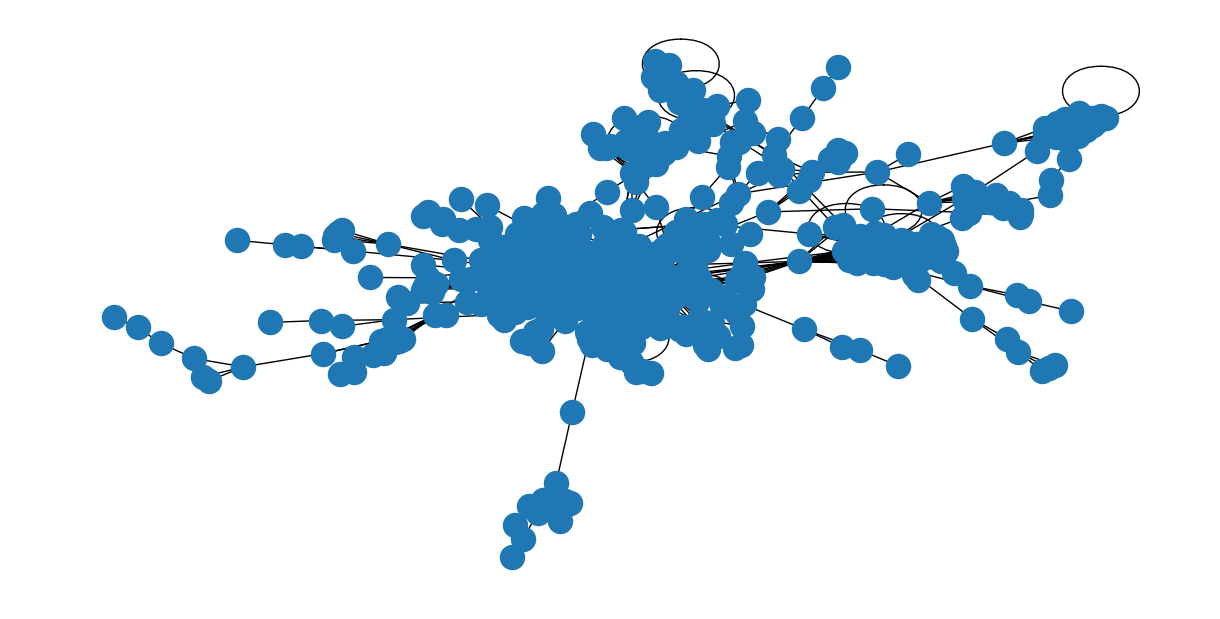

In [5]:
plt.figure(figsize=(12,6))
nx.draw(g)

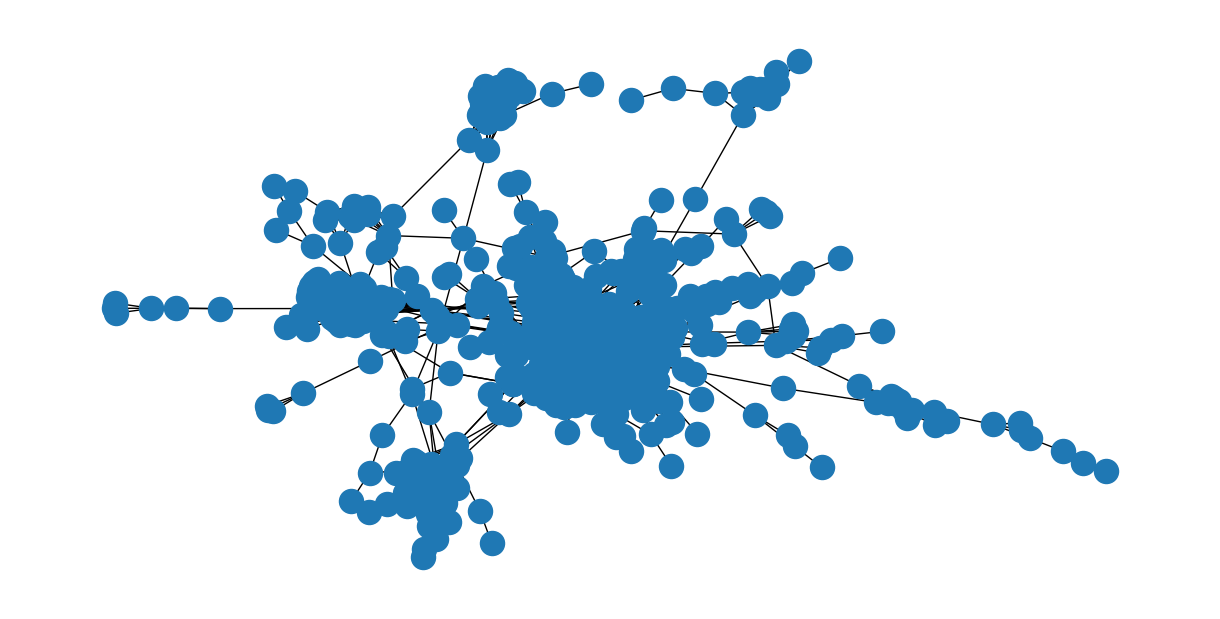

In [10]:
# удаляем петли
g.remove_edges_from(nx.selfloop_edges(g))
plt.figure(figsize=(12,6))
nx.draw(g)

In [11]:
nx.set_node_attributes(g, node_names, "name") #добавляем узлам атрибут name
g.nodes(data=True)

NodeDataView({'0': {'name': 'Lee Anne Wong'}, '276': {'name': 'KFC'}, '58': {'name': 'Chef Jamie Gwen'}, '132': {'name': 'Madison Cowan'}, '603': {'name': 'Elizabeth Karmel'}, '398': {'name': 'KFC'}, '555': {'name': 'KFC'}, '1': {'name': 'Pat Neely'}, '265': {'name': 'Logan Junior Chef'}, '611': {'name': 'Robin Miller'}, '2': {'name': 'Ben Sargent & Dr. Klaw'}, '182': {'name': 'Bobby Flay'}, '345': {'name': 'Chuck Hughes'}, '3': {'name': 'Chef Carlo Cracco'}, '608': {'name': 'Pasqualino Barbasso'}, '377': {'name': 'Alessandro Borghese'}, '40': {'name': 'Chef Hirohiko Shoda'}, '352': {'name': 'Alain Ducasse'}, '450': {'name': 'Christian Bau'}, '484': {'name': 'Andy Luotto'}, '299': {'name': "Cristian D'Elia"}, '65': {'name': 'Cuoco Filippo La Mantia'}, '185': {'name': 'Mirko Ronzoni'}, '228': {'name': 'Jock Zonfrillo'}, '557': {'name': 'Chef Maeve Rochford'}, '227': {'name': 'Wolfgang Puck'}, '90': {'name': 'Scott Conant'}, '151': {'name': 'Anne Burrell'}, '394': {'name': 'Steve Konopel

In [12]:
adj_matrix = nx.adjacency_matrix(g).todense()
adj_matrix

array([[0, 1, 1, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [13]:
#на основе этой матрицы считаем степени
degrees = np.array(adj_matrix.sum(axis=1)).flatten()
degrees


array([  6,   9,  15,   2,  27,   9,  17,   2, 132,  47,   3,  31,  11,
        10,   7,  10,   7,  19,   7,   3,  11,   8,   9,   2,   5,  15,
        51,  21,   1,   4,   2,  17,   2,   1,   2,   5,   7,   6,   3,
        10,  59,   7,   4,   4,   4,  22,   3,   4,   5,   2,  22,   2,
         7,   4,  28,  32,  37,   3,  26,   5,  14,  21,  26,  20,  43,
        10,  55,  25,  31,  47,  14,   5,  12,  14,  16,  56,  11,  33,
         2,   4,   7,   6,   6,  10,  12,   6,   7,   5,   3,   5,   6,
         1,   1,   2,   1,  47,   4,  35,  12,  15,  12,  13,  12,  12,
        22,  13,  11,  22,  13,  12,  16,   8,   9,   5,   1,   5,   5,
         8,  13,   8,   6,   9,   8,   1,  13,   9,   2,   4,  10,  12,
         4,   3,   6,   6,   3,  16,   6,   2,  10,  23,   5,   6,   9,
        13,   7,   3,   9,   5,   1,   9,   1,   1,   9,   3,  11,   7,
         1,   6,   1,   4,  25,   4,   6,  26,   6,   8,  15,   8,   6,
        13,  10,   4,   2,   5,  12,   7,   7,  11,   8,  29,   

In [14]:
max_degree_node = max(g.nodes, key=lambda node: g.degree(node))
max_degree_value = g.degree(max_degree_node)
g.nodes[max_degree_node],max_degree_node,max_degree_value

({'name': 'Logan Junior Chef'}, '265', 132)

<p class="task" id="2"></p>

2\. Используя граф из предыдущего задания, посчитайте степени каждого узла, используя возможности графа `nx.Graph`. Посчитайте и выведите на экран среднюю степень узлов графа, округленную до ближайшего целого.

- [ ] Проверено на семинаре

In [17]:
degrees2 = [deg for _, deg in g.degree()]
avg_degree = round(sum(degrees2) / len(degrees2))
avg_degree, np.mean(degrees)

(7, 6.745161290322581)

<p class="task" id="3"></p>

3\. Создайте ориентированный граф на основе набора данных `fb-pages-food` с сайта https://networkrepository.com/. Удалите из графа все петли. Получите матрицу смежности графа и посчитайте входящую и исходящую степень каждого узла на основе этой матрицы. Найдите и выведите на экран максимальное значение исходящих степеней и среднее значение входящих степеней.

- [ ] Проверено на семинаре

In [18]:
G = nx.read_adjlist('/content/fb-pages-food.edges',create_using=nx.DiGraph(), delimiter=',')

In [19]:
node_names = {}
with open("fb-pages-food.nodes", "r", encoding="utf-8") as f:
    reader = csv.reader(f)
    next(reader)
    for old_id, name, new_id in reader:
        node_names[new_id] = name

In [20]:
#удаляем петли
G.remove_edges_from(nx.selfloop_edges(G))

In [21]:
#матрица смежности графа
adj_matrix = nx.adjacency_matrix(G).todense()

In [22]:
in_degrees = np.sum(adj_matrix, axis=0).flatten()
out_degrees = np.sum(adj_matrix, axis=1).flatten()
max_out_degree = max(out_degrees)
avg_in_degree = round(sum(in_degrees) / len(in_degrees))

In [23]:
print(f"Максимальная исходящая степень: {max_out_degree}")
print(f"Средняя входящая степень: {avg_in_degree}")


Максимальная исходящая степень: 67
Средняя входящая степень: 3


<p class="task" id="4"></p>

4\. Постройте графики выборочной функции распределения входящих и исходящих степеней узлов для загруженного ориентированного графа. Для нахождения степеней узлов воспользуйтесь возможностями графа `nx.DiGraph`. Добавьте графикам названия, а осям - подписи. Расположите графики рядом по горизонтали.

- [ ] Проверено на семинаре

<p class="task" id="5"></p>

5\. Визуализируйте закон распределения степеней узлов в обычной и логарифимических (по 1й и по 2м осям) системах координат для неориентированного графа. Расположите графики в виде сетки 2х2. Добавьте графикам названия, а осям - подписи.

- [ ] Проверено на семинаре